In [ ]:
# Importing libraries for data visualization and data manipulation
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings as wr
import itertools
from scipy import statsb
import seaborn as sns

# Importing libraries for data preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Importing libraries for model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RepeatedStratifiedKFold, KFold

# Importing libraries for AI models

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor

# Importing libraries for feature selection
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

# Importing libraries for evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('ggplot')
wr.filterwarnings('ignore')
import lightgbm as lgb

In [150]:
test = pd.read_csv('/kaggle/input/home-data-for-ml-course/test.csv')
train = pd.read_csv('/kaggle/input/home-data-for-ml-course/train.csv')

In [151]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [152]:
train.dtypes[train.dtypes != 'object']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

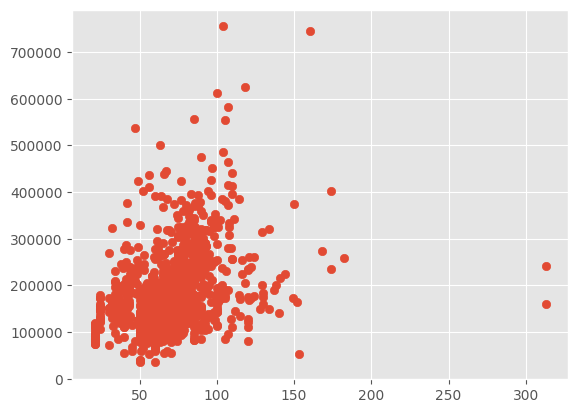

In [153]:
plt.scatter(x = 'LotFrontage', y = 'SalePrice', data=train)
plt.show()

In [154]:
train.query('LotFrontage > 300')

# Drop 935 and 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


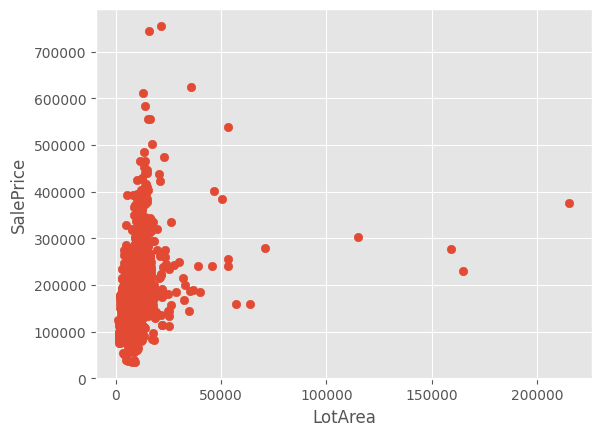

In [155]:
plt.scatter(x = 'LotArea', y ='SalePrice', data=train)
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()

In [156]:
train.query('LotArea > 55000')
#250, 314, 336, 707, 1299, 452
# maybe 1397

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [157]:
pd.Series(stats.zscore(train['LotArea'])).sort_values().tail(10)

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
dtype: float64

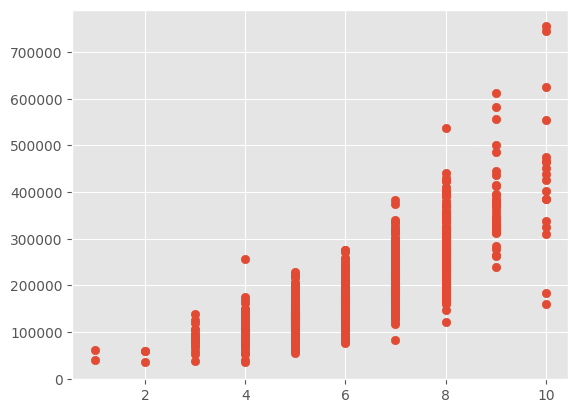

In [158]:
plt.scatter(x = 'OverallQual', y='SalePrice', data = train)

In [159]:
train.query('OverallQual == 10')
# drop 1299,524

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
224,225,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,New,Partial,426000
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
591,592,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,451950
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


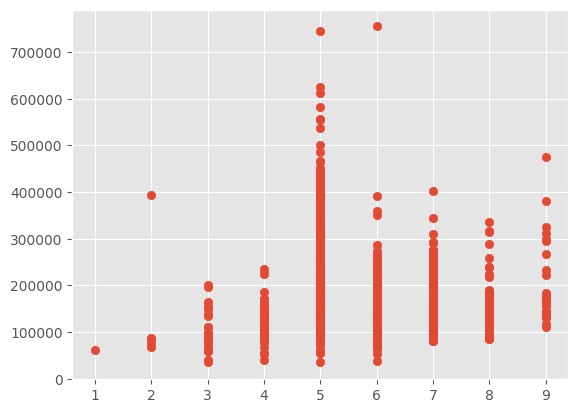

In [160]:
plt.scatter(x = 'OverallCond', y = 'SalePrice', data = train)

In [161]:
train.query('OverallCond == 6 & SalePrice > 700000' )
# 379, 1183, 692

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


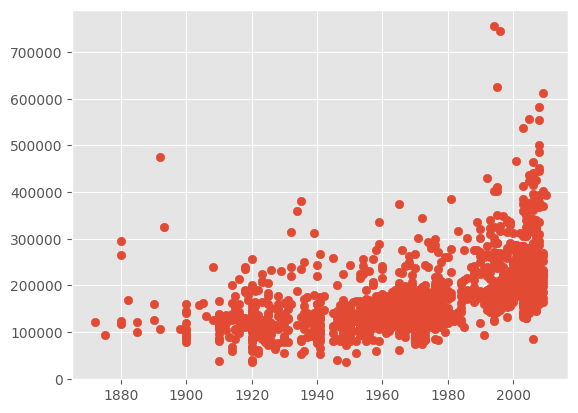

In [162]:
plt.scatter(x = 'YearBuilt' , y = 'SalePrice', data = train)
plt.show()

In [163]:
train.query('YearBuilt < 1900 & SalePrice > 400000')
# 186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


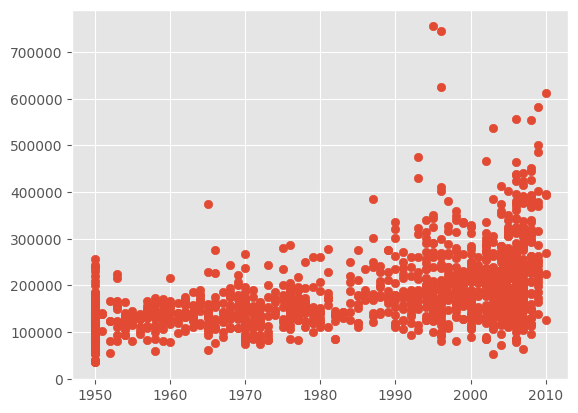

In [164]:
plt.scatter(x = 'YearRemodAdd', y = 'SalePrice', data = train)

In [165]:
train.query('YearRemodAdd < 2000 & SalePrice > 700000')
# 692, 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


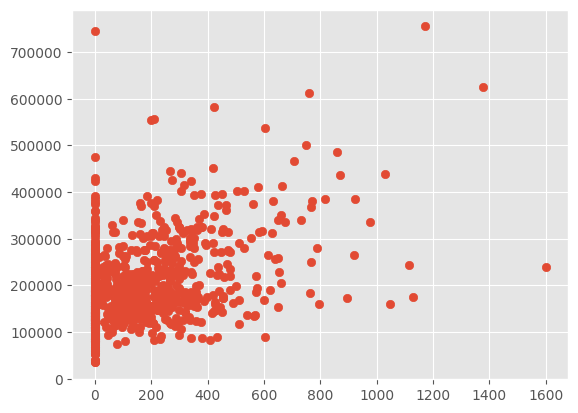

In [166]:
plt.scatter(x = 'MasVnrArea', y = 'SalePrice', data = train)

In [167]:
train.query('MasVnrArea > 1500')
# 298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,239000


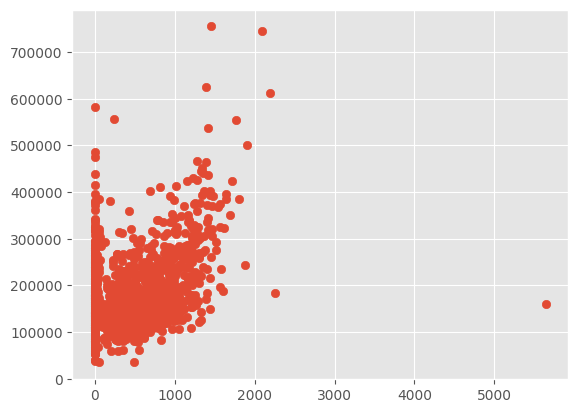

In [168]:
plt.scatter(x = 'BsmtFinSF1', y = 'SalePrice', data = train)

In [169]:
train.query('BsmtFinSF1 > 5000')
# 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


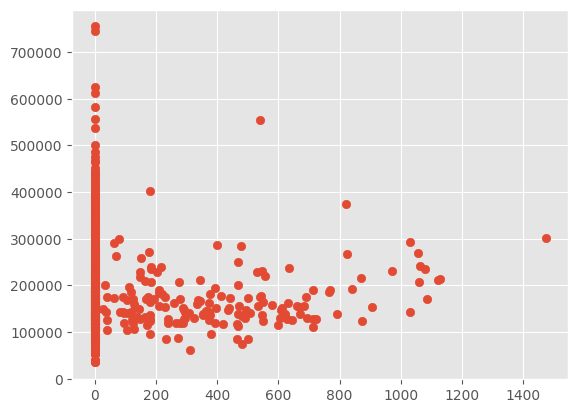

In [170]:
plt.scatter(x = 'BsmtFinSF2', y = 'SalePrice', data = train)

In [171]:
train.query('BsmtFinSF2 > 400 & SalePrice > 400000')
# 323, 441

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


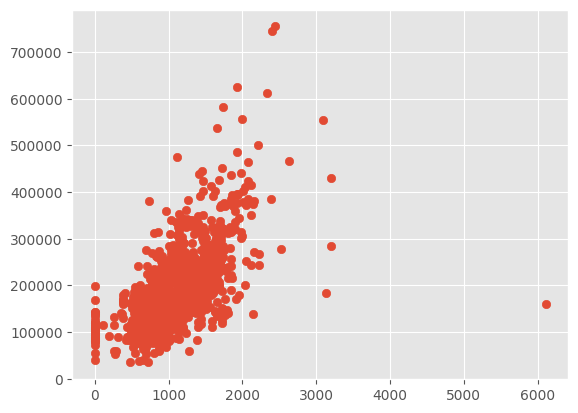

In [172]:
plt.scatter(x = 'TotalBsmtSF', y = 'SalePrice', data=train)

In [173]:
train.query('TotalBsmtSF > 6000')
# 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


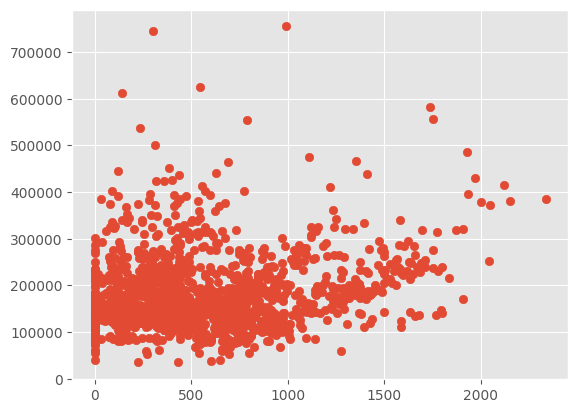

In [174]:
plt.scatter(x = 'BsmtUnfSF', y = 'SalePrice', data=train)

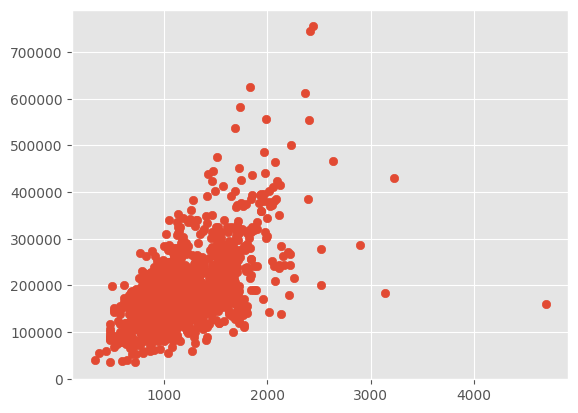

In [175]:
plt.scatter(x = '1stFlrSF', y = 'SalePrice', data=train)

In [176]:
train.query('`1stFlrSF` > 4000')
# 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


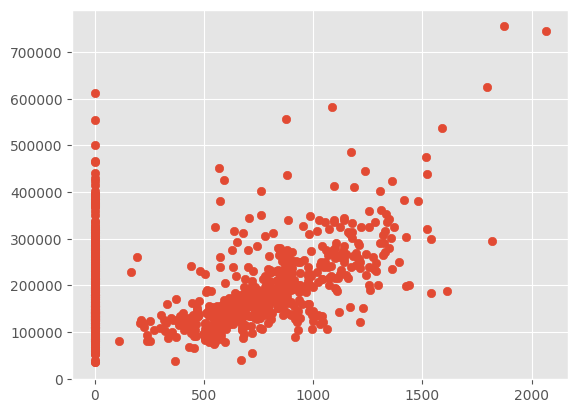

In [177]:
plt.scatter(x = '2ndFlrSF', y = 'SalePrice', data=train)

In [178]:
train.query('`2ndFlrSF` > 1700')
# 305, 692, 1170, 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
304,305,75,RM,87.0,18386,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,295000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


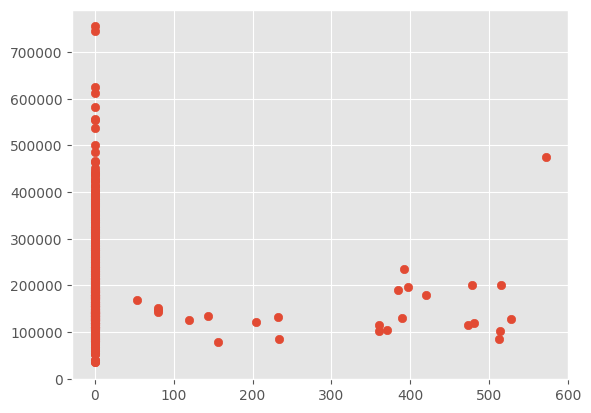

In [179]:
plt.scatter(x = 'LowQualFinSF', y = 'SalePrice', data = train)

In [180]:
train.query('LowQualFinSF > 500')
#186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
170,171,50,RM,NaN,12358,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,128500
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000
1009,1010,50,RL,60.0,6000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,102000


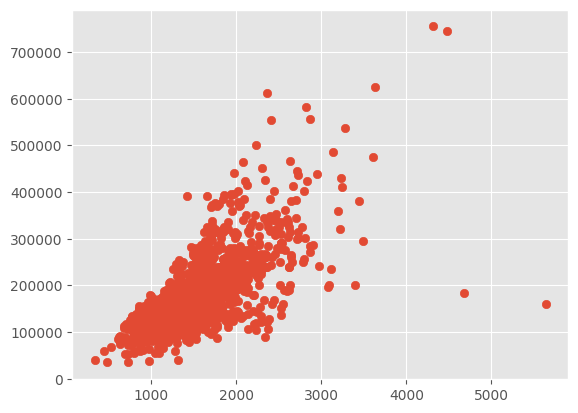

In [181]:
plt.scatter(x = 'GrLivArea', y = 'SalePrice', data = train)

In [182]:
train.query('GrLivArea > 4400')
#524, 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


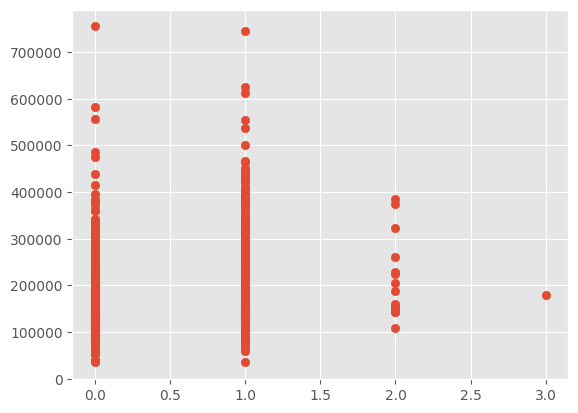

In [183]:
plt.scatter(x = 'BsmtFullBath' , y = 'SalePrice', data = train)

In [184]:
train.query('BsmtFullBath == 3')
# 739

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000


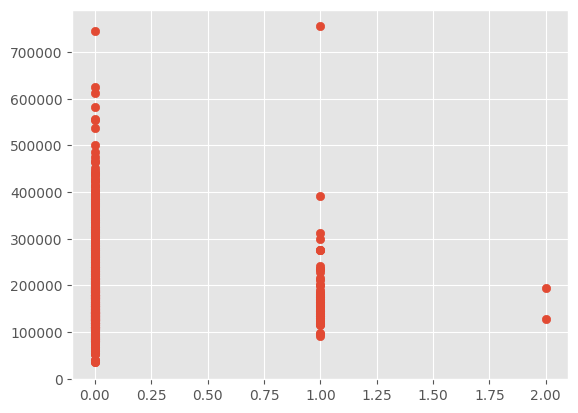

In [185]:
plt.scatter(x = 'BsmtHalfBath' , y = 'SalePrice', data = train)

In [186]:
pd.Series(stats.zscore(train['BsmtHalfBath'])).unique()

array([-0.24106104,  3.94880935,  8.13867973])

In [187]:
train.query('BsmtHalfBath == 2')
# 598, 955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


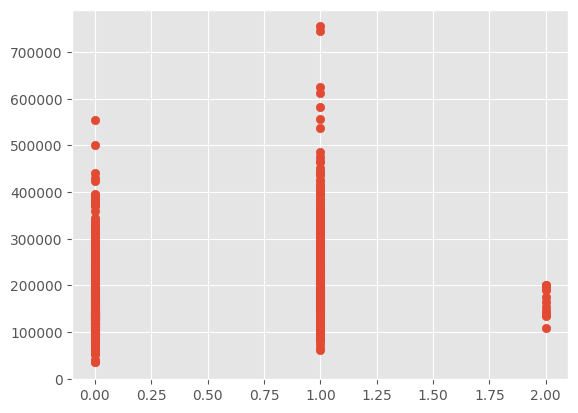

In [188]:
plt.scatter(x = 'HalfBath' , y = 'SalePrice', data = train)

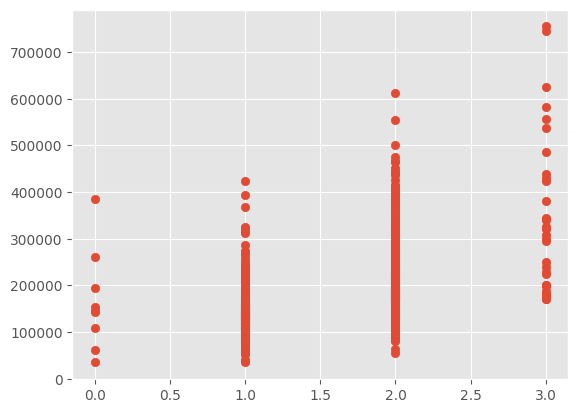

In [189]:
plt.scatter(x = 'FullBath' , y = 'SalePrice', data = train)

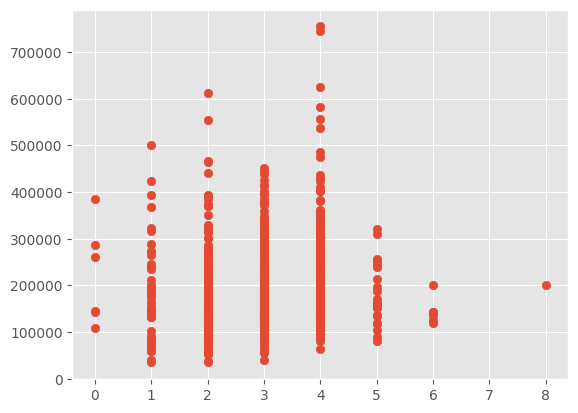

In [190]:
plt.scatter(x = 'BedroomAbvGr' , y = 'SalePrice', data = train)

In [191]:
train.query('BedroomAbvGr == 8')
# 636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


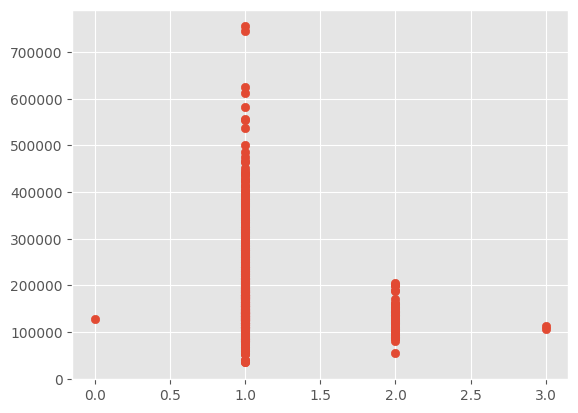

In [192]:
plt.scatter(x = 'KitchenAbvGr' , y = 'SalePrice', data = train)

In [193]:
train.query('KitchenAbvGr == 3.0')
# 955, 49, 810

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000


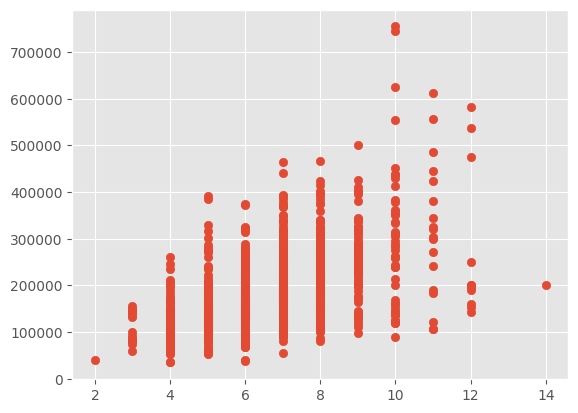

In [194]:
plt.scatter(x = 'TotRmsAbvGrd' , y = 'SalePrice', data = train)

In [195]:
train.query('TotRmsAbvGrd == 2')
# 636, 534

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
533,534,20,RL,50.0,5000,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,39300


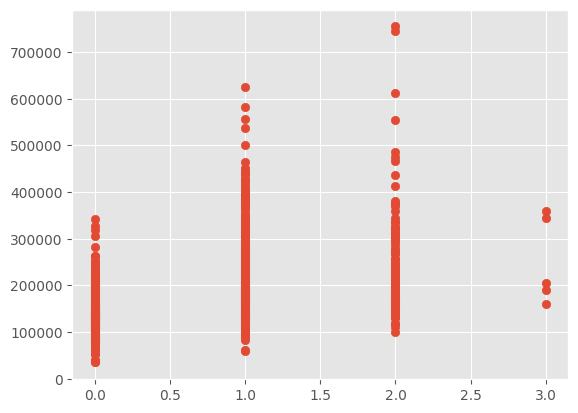

In [196]:
plt.scatter(x = 'Fireplaces' , y = 'SalePrice', data = train)

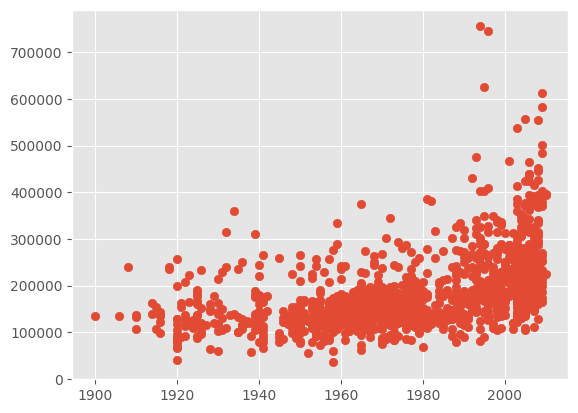

In [197]:
plt.scatter(x = 'GarageYrBlt' , y = 'SalePrice', data = train)

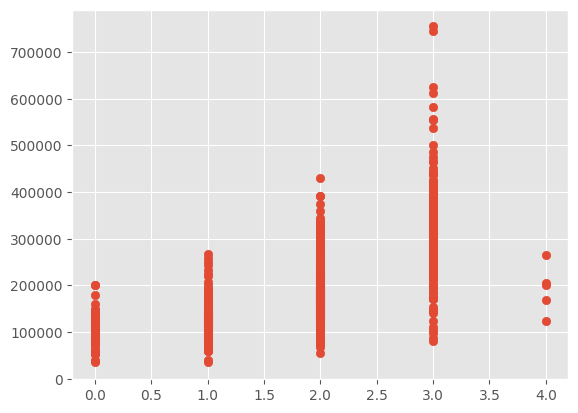

In [198]:
plt.scatter(x = 'GarageCars' , y = 'SalePrice', data = train)

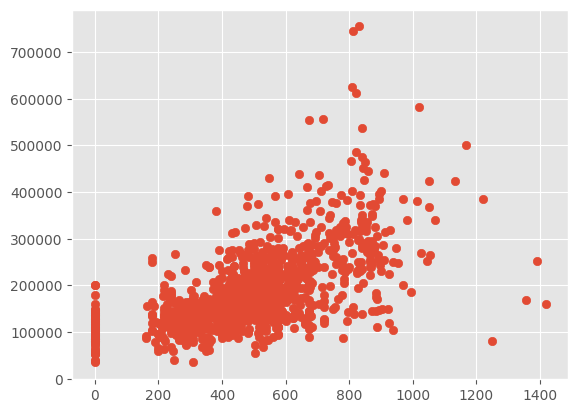

In [199]:
plt.scatter(x = 'GarageArea' , y = 'SalePrice', data = train)

In [200]:
train.query('GarageArea > 1200')
# 1062, 1191

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


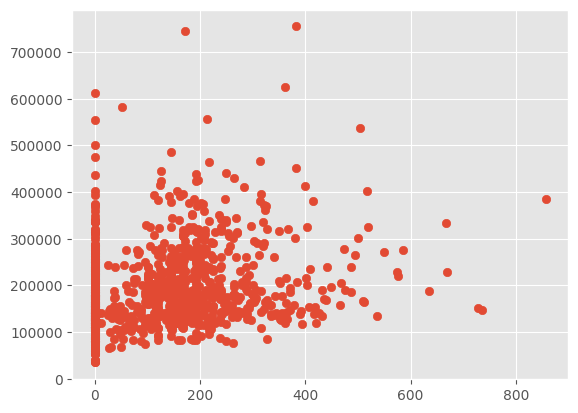

In [201]:
plt.scatter(x = 'WoodDeckSF' , y = 'SalePrice', data = train)

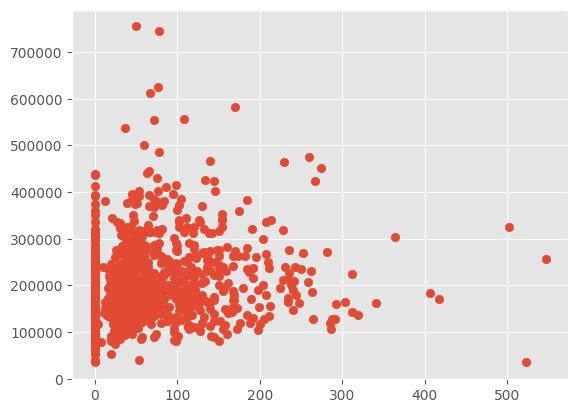

In [202]:
plt.scatter(x = 'OpenPorchSF' , y = 'SalePrice', data = train)

In [203]:
train.query('OpenPorchSF > 500')
# 496

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000


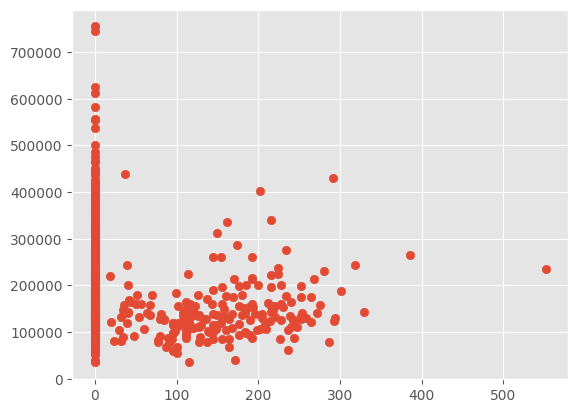

In [204]:
plt.scatter(x = 'EnclosedPorch' , y = 'SalePrice', data = train)

In [205]:
train.query('EnclosedPorch > 500')
# 198

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000


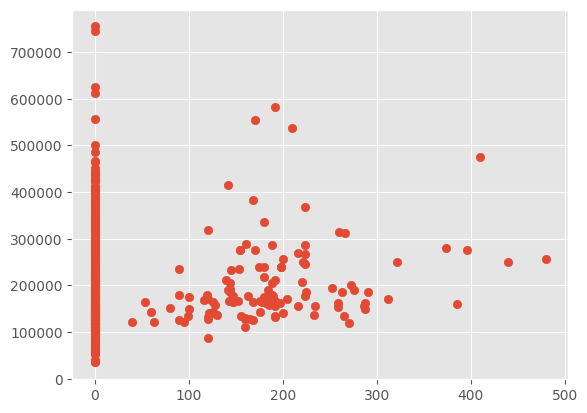

In [206]:
plt.scatter(x = 'ScreenPorch' , y = 'SalePrice', data = train)

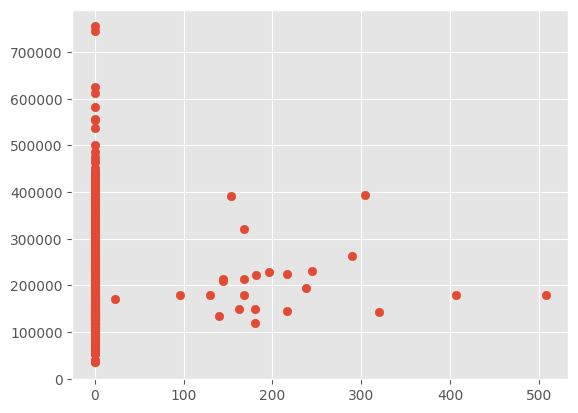

In [207]:
plt.scatter(x = '3SsnPorch' , y = 'SalePrice', data = train)

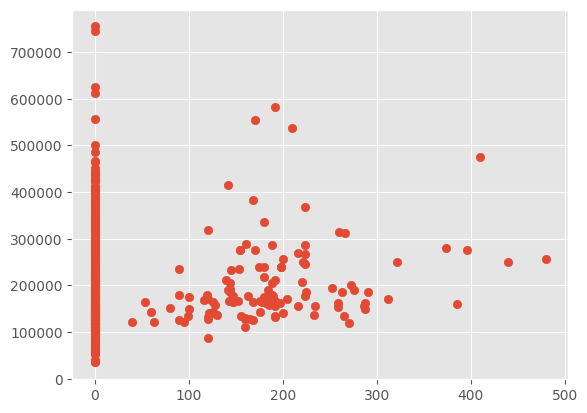

In [208]:
plt.scatter(x = 'ScreenPorch' , y = 'SalePrice', data = train)

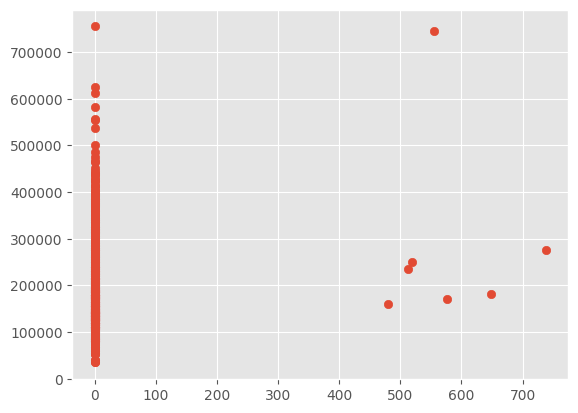

In [209]:
plt.scatter(x = 'PoolArea' , y = 'SalePrice', data = train)

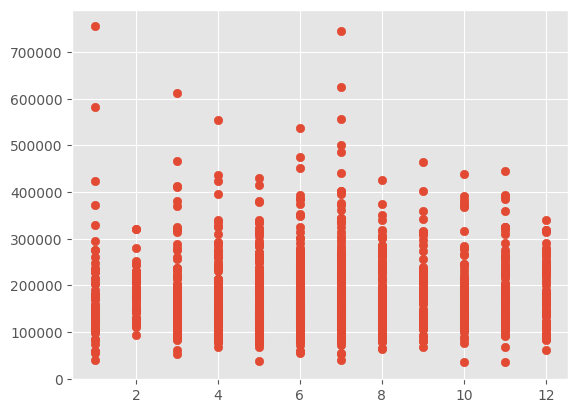

In [210]:
plt.scatter(x = 'MoSold' , y = 'SalePrice', data = train)

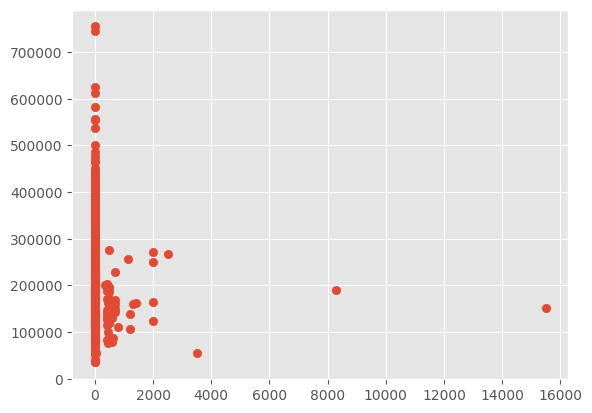

In [211]:
plt.scatter(x = 'MiscVal' , y = 'SalePrice', data = train)

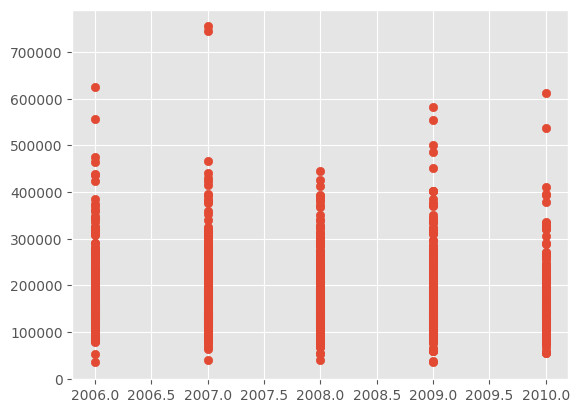

In [212]:
plt.scatter(x = 'YrSold' , y = 'SalePrice', data = train)

In [213]:
values = [598, 955, 935, 1299, 250, 314, 336, 707, 379, 1183, 692, 186, 441, 186, 524, 739, 598, 955, 636, 1062, 1191, 496, 198, 1338]

In [214]:
train = train[train.Id.isin(values = [598, 955, 935, 1299, 250, 314, 336, 707, 379, 1183, 692, 186, 441, 186, 524, 739, 598, 955, 636, 1062, 1191, 496, 198, 1338]) == False]

In [215]:
pd.DataFrame(train.isnull().sum().sort_values(ascending = False)).head(20)

,0
PoolQC,1435
MiscFeature,1388
Alley,1350
Fence,1162
MasVnrType,861
FireplaceQu,684
LotFrontage,255
GarageQual,76
GarageFinish,76
GarageType,76


In [216]:
train['Alley'].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [217]:
train['Alley'].fillna('No', inplace=True)
test['Alley'].fillna('No', inplace=True)

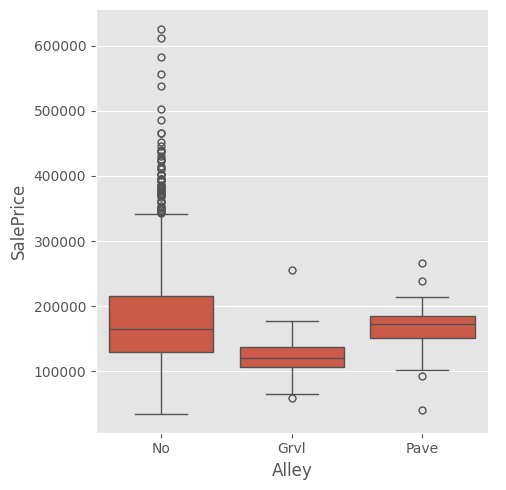

In [218]:
sns.catplot(data=train, x="Alley", y="SalePrice", kind="box")


In [219]:
train.query('Alley == "Pave"').count()

Id               40
MSSubClass       40
MSZoning         40
LotFrontage      38
LotArea          40
                 ..
MoSold           40
YrSold           40
SaleType         40
SaleCondition    40
SalePrice        40
Length: 81, dtype: int64

In [220]:
train['Fence'].unique()

array([nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [221]:
train['Fence'].fillna('No', inplace=True)
test['Fence'].fillna('No', inplace=True)

In [222]:
train['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [223]:
train['MasVnrType'].fillna('No', inplace = True)
test['MasVnrType'].fillna('No', inplace=True)

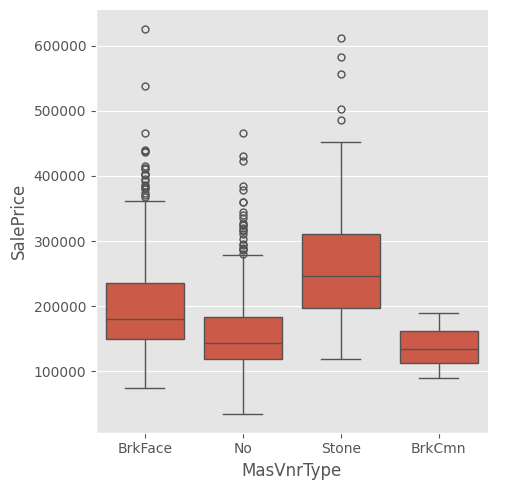

In [224]:
sns.catplot(data=train, x="MasVnrType", y="SalePrice", kind="box")

In [225]:
train['MasVnrArea'].fillna(0, inplace = True)
test['MasVnrArea'].fillna(0, inplace=True)

In [226]:
train['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [227]:
train['FireplaceQu'].fillna('No', inplace = True)
test['FireplaceQu'].fillna('No', inplace=True)

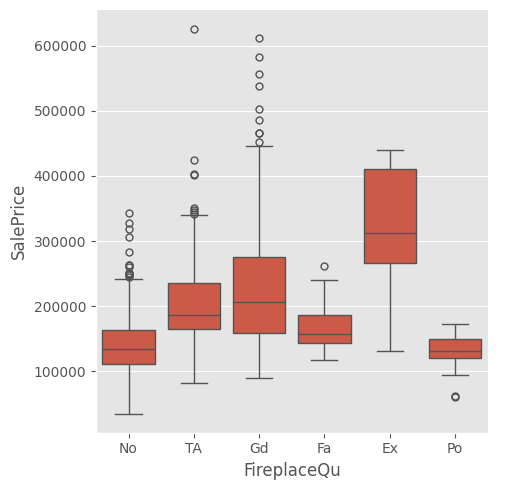

In [228]:
sns.catplot(data=train, x="FireplaceQu", y="SalePrice", kind="box")

In [229]:
train['Fireplaces'].unique()

array([0, 1, 2, 3])

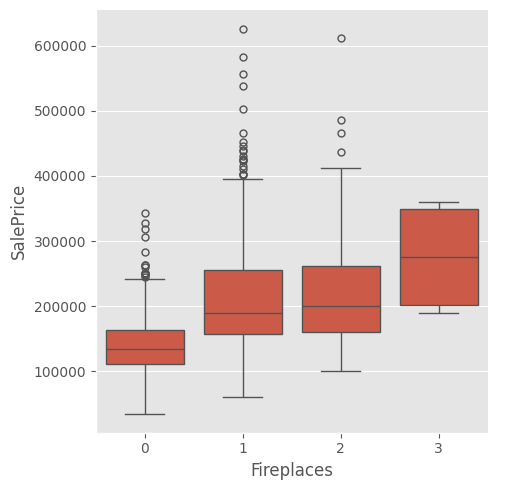

In [230]:
sns.catplot(data=train, x="Fireplaces", y="SalePrice", kind="box")

In [231]:
train['LotFrontage'].fillna(0, inplace = True)
test['LotFrontage'].fillna(0, inplace=True)

In [232]:
train['GarageYrBlt'].corr(train['YearBuilt'])

np.float64(0.8289827595060575)

In [233]:
train['GarageCond'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [234]:
train['GarageCond'].fillna('No', inplace = True)
test['GarageCond'].fillna('No', inplace=True)

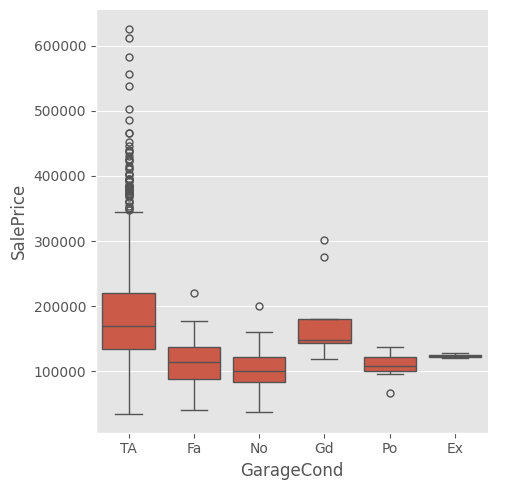

In [235]:
sns.catplot(data=train, x="GarageCond", y="SalePrice", kind="box")

In [236]:
train['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [237]:
train['GarageType'].fillna('No', inplace=True)
test['GarageType'].fillna('No', inplace = True)

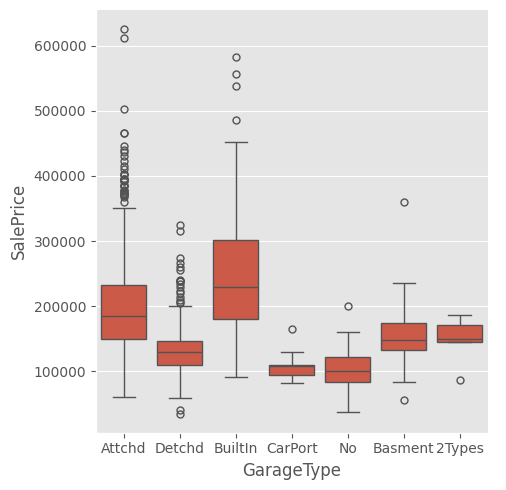

In [238]:
sns.catplot(data=train, x="GarageType", y="SalePrice", kind="box")

In [239]:
train['GarageFinish'].unique()

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

In [240]:
train['GarageFinish'].fillna('No', inplace=True)
test['GarageFinish'].fillna('No', inplace = True)

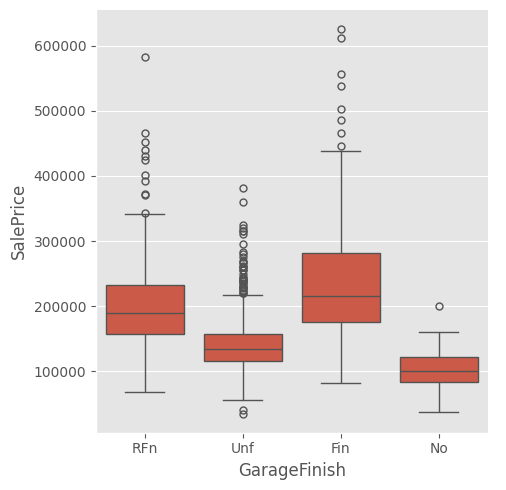

In [241]:
sns.catplot(data=train, x="GarageFinish", y="SalePrice", kind="box")

In [242]:
train['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', nan, 'Po', 'Ex'], dtype=object)

In [243]:
train['GarageQual'].fillna('No', inplace=True)
test['GarageQual'].fillna('No', inplace = True)

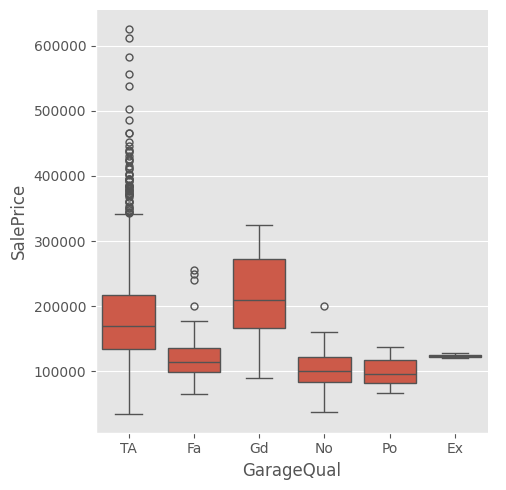

In [244]:
sns.catplot(data=train, x="GarageQual", y="SalePrice", kind="box")

In [245]:
train['BsmtFinType2'].unique()

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [246]:
train['BsmtFinType2'].fillna('Unf', inplace=True)
test['BsmtFinType2'].fillna('Unf', inplace = True)

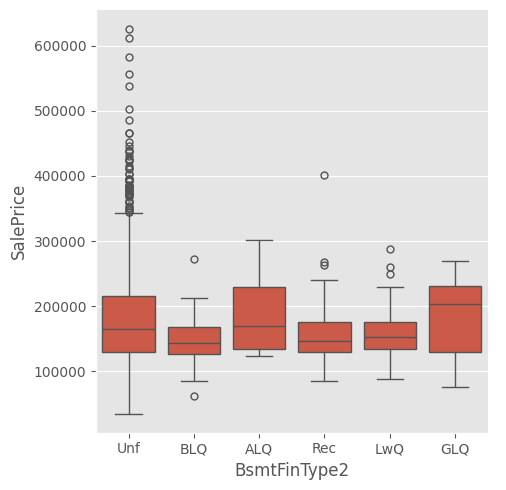

In [247]:
sns.catplot(data=train, x="BsmtFinType2", y="SalePrice", kind="box")

In [248]:
train['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [249]:
train['BsmtExposure'].fillna('No', inplace=True)
test['BsmtExposure'].fillna('No', inplace = True)

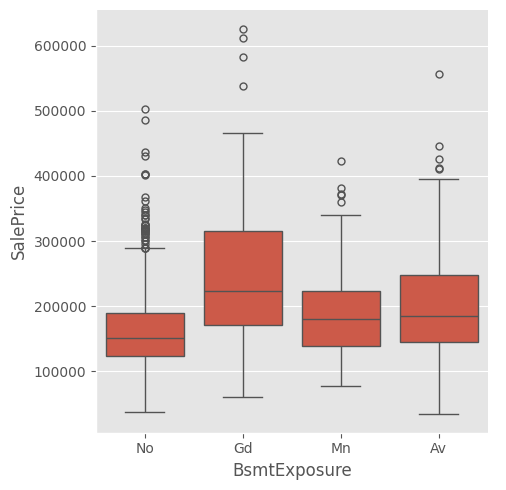

In [250]:
sns.catplot(data=train, x="BsmtExposure", y="SalePrice", kind="box")

In [251]:
train['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [252]:
train['BsmtQual'].fillna('No', inplace=True)
test['BsmtQual'].fillna('No', inplace=True)

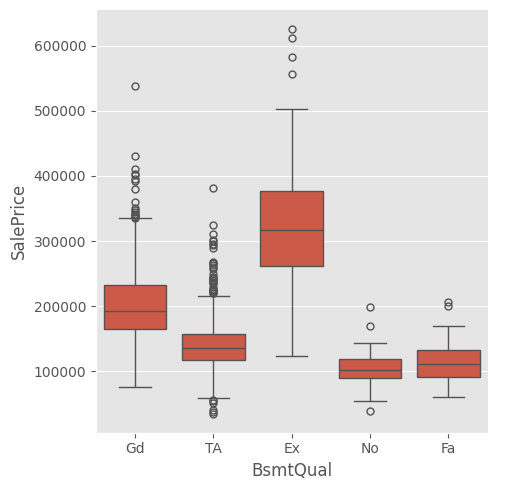

In [253]:
sns.catplot(data=train, x="BsmtQual", y="SalePrice", kind="box")

In [254]:
train['BsmtCond'].unique()

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

In [255]:
train['BsmtCond'].fillna('No', inplace=True)
test['BsmtCond'].fillna('No', inplace=True)

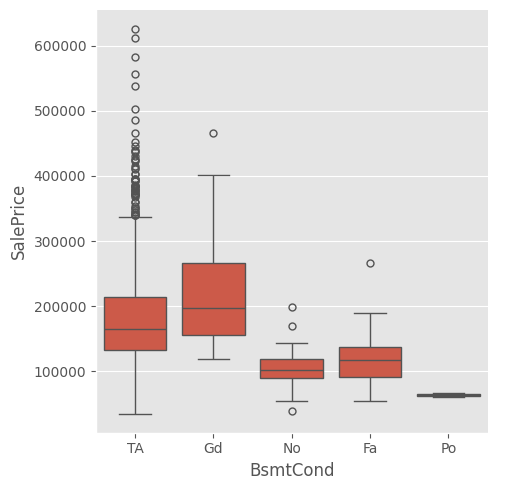

In [256]:
sns.catplot(x = 'BsmtCond', y = 'SalePrice', kind = 'box', data=train)

In [257]:
train['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [258]:
train['BsmtFinType1'].fillna('No', inplace=True)
test['BsmtFinType1'].fillna('No',inplace = True)

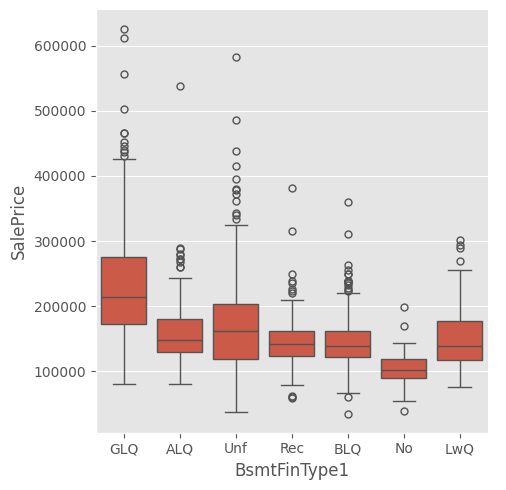

In [259]:
sns.catplot(x = 'BsmtFinType1', y = 'SalePrice', kind = 'box', data=train)

In [260]:
train['MasVnrArea'].fillna(0, inplace=True)
test['MasVnrArea'].fillna(0,inplace = True)

In [261]:
train['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [262]:
train['Electrical'].fillna('SBrkr', inplace = True)
test['Electrical'].fillna('SBrkr', inplace= True)

In [263]:
train = train.drop(columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])
test = test.drop(columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])

# Feature Engineering

In [264]:
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

In [265]:
train['HouseRemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['HouseRemodAge'] = test['YrSold'] - test['YearRemodAdd']

In [266]:
train['TotalSF'] = train['1stFlrSF'] + train['2ndFlrSF'] + train['BsmtFinSF1'] + train['BsmtFinSF2']
test['TotalSF'] = test['1stFlrSF'] + test['2ndFlrSF'] + test['BsmtFinSF1'] + test['BsmtFinSF2']

In [267]:
train['TotalArea'] = train['GrLivArea'] + train['TotalBsmtSF']
test['TotalArea'] = test['GrLivArea'] + test['TotalBsmtSF']

In [268]:
train['TotalBaths'] = train['BsmtFullBath'] + train['FullBath'] + 0.5 * (train['BsmtHalfBath'] + train['HalfBath']) 
test['totalbaths'] = test['BsmtFullBath'] + test['FullBath'] + 0.5 * (test['BsmtHalfBath'] + test['HalfBath']) 

In [269]:
train['TotalPorchSF'] = train['OpenPorchSF'] + train['EnclosedPorch'] + train['3SsnPorch'] + train['ScreenPorch']
test['TotalPorchSF'] = test['OpenPorchSF'] + test['EnclosedPorch'] + test['3SsnPorch'] + test['ScreenPorch']

In [270]:
train = train.drop(columns = ['Id', 'YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2',\
                             'GrLivArea', 'TotalBsmtSF', 'BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF',\
                              'EnclosedPorch', '3SsnPorch', 'ScreenPorch'])
test = test.drop(columns = ['Id', 'YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2',\
                             'GrLivArea', 'TotalBsmtSF', 'BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF',\
                              'EnclosedPorch', '3SsnPorch', 'ScreenPorch'])

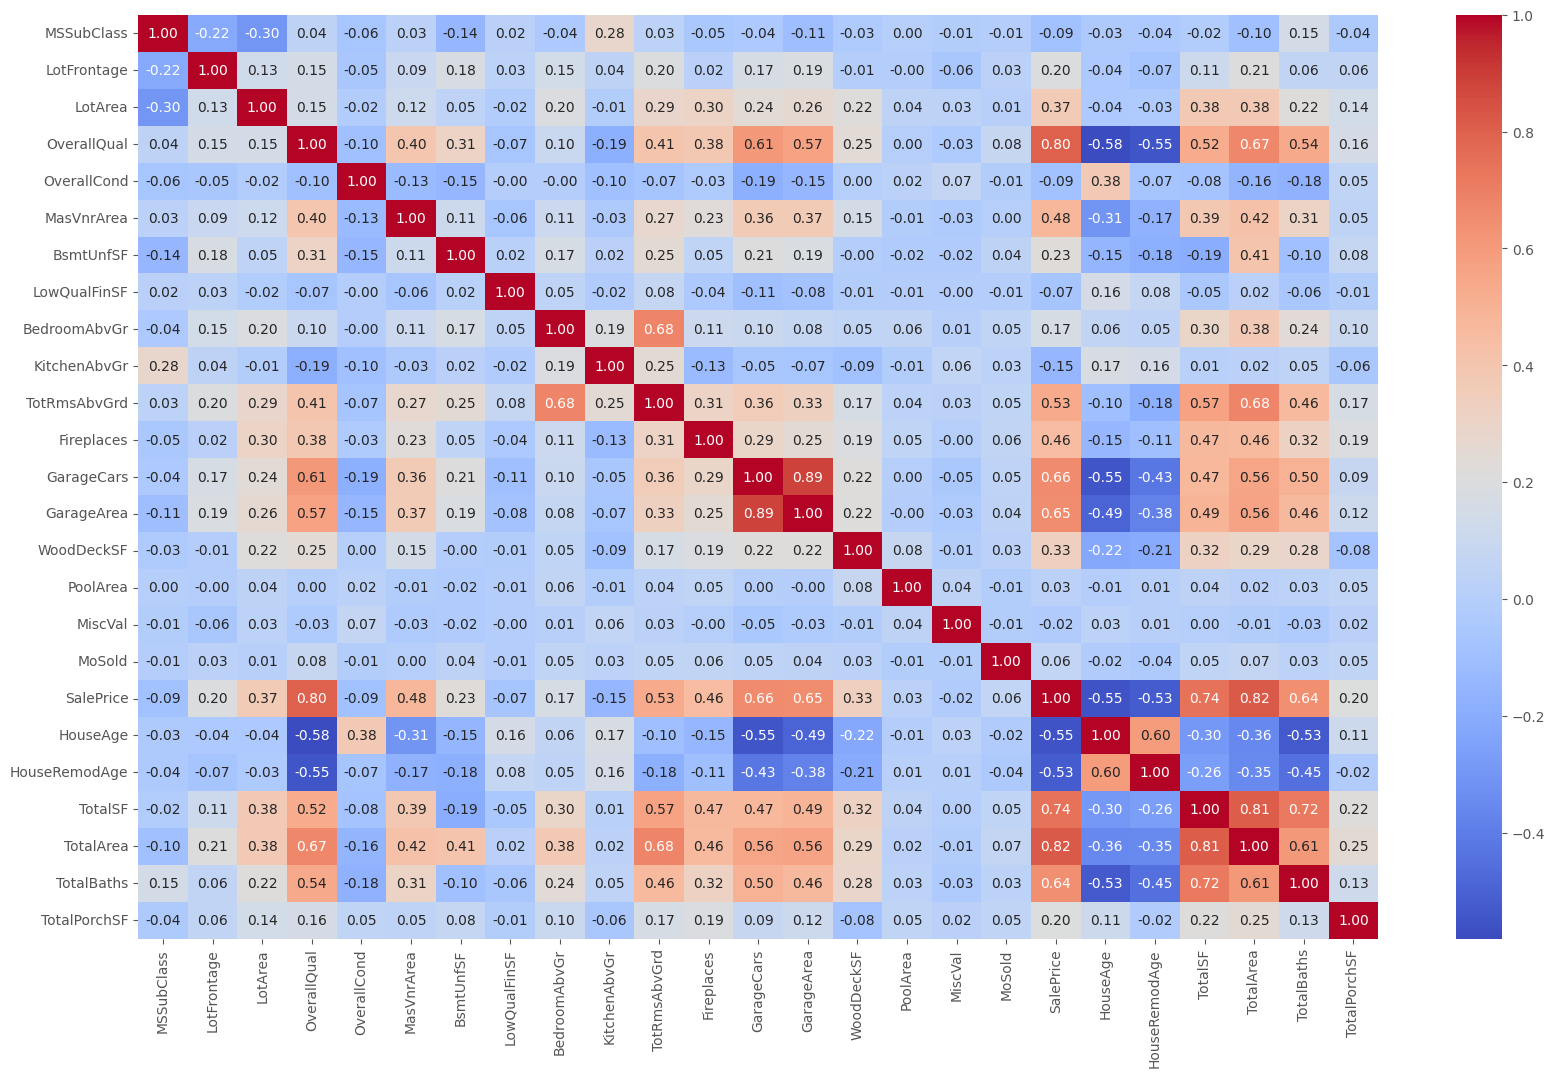

In [271]:
corr_mat = train.corr(numeric_only=True)
plt.figure(figsize = (20, 12))
sns.heatmap(corr_mat, cmap = 'coolwarm',fmt = '.2f',annot= True)
plt.show()

In [272]:
#Drop GarageArea or GarageCars

In [273]:
train = train.drop(columns = ['GarageArea'])
test = test.drop(columns = ['GarageArea'])

<Axes: xlabel='SalePrice', ylabel='Count'>

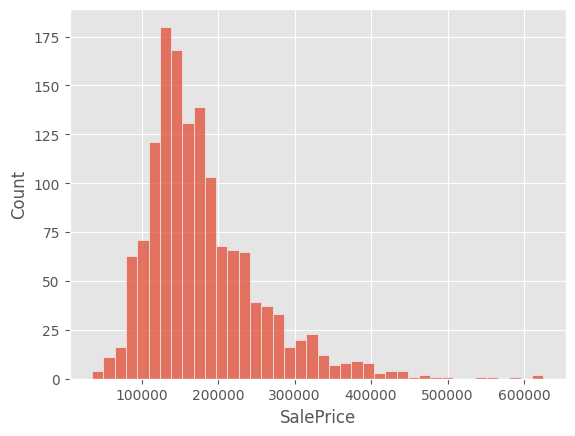

In [274]:
sns.histplot(
    train,
    x=train['SalePrice']
)

In [275]:
train['SalePrice'] = np.log1p(train['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

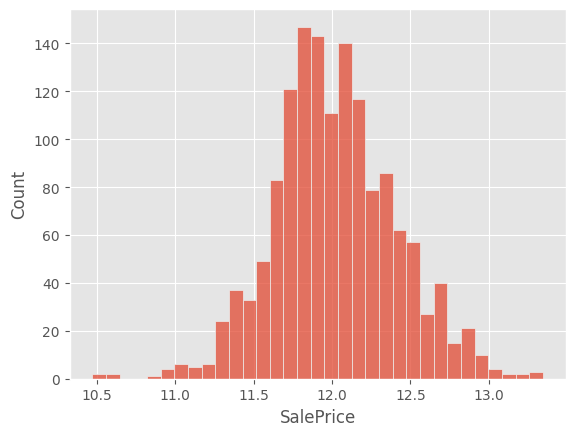

In [276]:
sns.histplot(
    train,
    x = train['SalePrice']
)

In [277]:
train.dtypes[train.dtypes == 'object']

MSZoning         object
Street           object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
PavedDrive       object
SaleType         object
SaleCondition    object
dtype: object

In [278]:
train.dtypes[train.dtypes != 'object']

MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
MasVnrArea       float64
BsmtUnfSF          int64
LowQualFinSF       int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageCars         int64
WoodDeckSF         int64
PoolArea           int64
MiscVal            int64
MoSold             int64
SalePrice        float64
HouseAge           int64
HouseRemodAge      int64
TotalSF            int64
TotalArea          int64
TotalBaths       float64
TotalPorchSF       int64
dtype: object

In [279]:
num_cols = train.select_dtypes(include = ['int64', 'float64']).columns.tolist()
num_cols.remove('SalePrice')

In [280]:
ode_cols = ['LotShape', 'LandContour', 'Utilities', 'LandSlope', 'BsmtQual', 'BsmtFinType1', 'CentralAir', 'Functional', \
           'FireplaceQu', 'GarageFinish', 'GarageQual', 'PavedDrive', 'ExterCond', 'KitchenQual', 'BsmtExposure', \
            'HeatingQC','ExterQual', 'BsmtCond']

In [281]:
ohe_cols = ['Street', 'LotConfig','Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',\
            'Exterior1st', 'Exterior2nd','MasVnrType','Foundation','Electrical',  'SaleType', 'MSZoning', 'SaleCondition',\
            'Heating', 'GarageType', 'RoofMatl']

In [282]:
num_pipeline = Pipeline(steps = [
    ('impute', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler())
])

In [283]:
ode_pipeline = Pipeline(steps = [
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [284]:
ohe_pipeline = Pipeline(steps = [
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [285]:
col_trans = ColumnTransformer(transformers = [
    ('num_p', num_pipeline, num_cols),
    ('ode_p', ode_pipeline, ode_cols),
    ('ohe_p', ohe_pipeline, ohe_cols),
    ],
    remainder = 'passthrough',
    n_jobs = -1
)

In [286]:
pipeline = Pipeline(steps = [
    ('preprocessing', col_trans)
])

In [287]:
X = train.drop('SalePrice', axis = 1)
y = train['SalePrice']

In [288]:
X_preprocessed = pipeline.fit_transform(X)

In [289]:
X_preprocessed

array([[ 0.07887505,  0.24496024, -0.28610364, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87291695,  0.70183977, -0.07084665, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07887505,  0.33633615,  0.23800033, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.31682305,  0.27541888, -0.17529308, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87291695,  0.33633615, -0.04894659, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87291695,  0.54954659, -0.00776699, ...,  0.        ,
         0.        ,  0.        ]])

In [290]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size = 0.2, random_state = 10)

In [291]:
lr = LinearRegression()

In [292]:
lr.fit(X_train, y_train)

LinearRegression()

In [293]:
y_pred_lr = lr.predict(X_test)

In [294]:
mean_squared_error(y_test, y_pred_lr)

0.014382966744511453

In [295]:
rfr = RandomForestRegressor()

In [297]:
param_grid_rfr = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 250, 500],
    'min_samples_split': [3, 5, 10]
}

In [298]:
rfr_cv = GridSearchCV(rfr, param_grid_rfr, cv = 5, scoring = 'neg_mean_squared_error', n_jobs= -1)

In [ ]:
rfr_cv.fit(X_train, y_train)

In [ ]:
y_pred_rfr = rfr_cv.predict(X_test)

In [ ]:
np.sqrt(-1 * rfr_cv.best_score)

In [ ]:
rfr_cv.best_params_

In [ ]:
XGB = XGBRegressor(random_state=20)

In [ ]:
param_grd_XGB = {
    'learning_rate' : [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1, 2, 3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [ ]:
XGB_cv = GridSearchCV(XGB, param_grid_XGB, cv = 5, scoring = 'neg_mean_squared_error', n_jobs= -1)

In [ ]:
XGB_cv.fit(X_train, y_train)

In [ ]:
y_pred_XGB = XGB_cv.predict(X_test)

In [ ]:
np.sqrt(-1 * XGB_cv.best_score)

In [ ]:
XGB_cv.best_params_